# Signal Decomposition Using Tucker

In [5]:
from scipy.linalg import hankel, svd
from scipy.signal.windows import hann
from tensorly.decomposition import tucker
from sklearn.decomposition import FastICA
from loguru import logger

import numpy as np
import matplotlib.pyplot as plt
import neurokit2 as nk
import tensorly as tl

import os, wget, gc
import pyedflib
import torch

In [2]:
# # Run this cell only if you need to download the dataset
# !cd .. && mkdir data\raw && cd data\raw
# !python -m wget https://physionet.org/files/adfecgdb/1.0.0/r01.edf -o ../data/raw/r01.edf
# !python -m wget https://physionet.org/files/adfecgdb/1.0.0/r01.edf -o ../data/raw/r04.edf
# !python -m wget https://physionet.org/files/adfecgdb/1.0.0/r01.edf -o ../data/raw/r07.edf
# !python -m wget https://physionet.org/files/adfecgdb/1.0.0/r01.edf -o ../data/raw/r08.edf
# !python -m wget https://physionet.org/files/adfecgdb/1.0.0/r01.edf -o ../data/raw/r10.edf

In [6]:
# please run EdfReader only once otherwise it will throw an error
edf_path = os.path.join("..", "data", "raw", "r01.edf")

try:
    edf = pyedflib.EdfReader(edf_path)
except:
    edf._close() # type: ignore
    del edf # type: ignore
    edf = pyedflib.EdfReader(edf_path)

In [7]:
def get_signal_segment(ch_number: int = 0, start_time: float = 0.0, end_time: float = 5.0):
    sampling_rate = edf.getSampleFrequency(ch_number)
    signal = edf.readSignal(ch_number)
    ons, _, _ = edf.readAnnotations()
    
    start_idx = int(start_time * sampling_rate)
    end_idx = int(end_time * sampling_rate)
    
    segment = signal[start_idx:end_idx]
    time = np.linspace(start_time, end_time, len(segment))
    onsets = ons[(ons >= start_time) & (ons <= end_time)]
    values = np.interp(onsets, time, segment)
    
    # return a dictionary with segment, time, onsets, and values
    return {
        "sampling_rate": sampling_rate,
        "segment": segment,
        "time": time,
        "onsets": onsets,
        "values": values
    }
    
    
def plot_signal(signal: np.ndarray, time: np.ndarray, onsets: np.ndarray = None, values: np.ndarray = None, filename: str = None):
    plt.figure(figsize=(15, 5))
    plt.plot(time, signal, label="Signal")
    
    if onsets is not None and values is not None:
        plt.scatter(onsets, values, color='red', label="R-peaks")
    
    plt.title("ECG Signal")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.grid()
    plt.legend()
    plt.show()
    
    if filename:
        plt.savefig(filename)


def lower_peaks(signal, sampling_rate: int = 1000, peaks: np.ndarray = [], reduction_factor=0.2, neighborhood: int = 70, show: bool = False):
    _, info = nk.ecg_peaks(-signal, sampling_rate=sampling_rate, correct_artifacts=True)
    
    # if peaks == []:
    #     peaks = info['ECG_R_Peaks']

    clean_signal = signal.copy()
    for i in range(len(peaks)):
        left_potential = peaks[i] - neighborhood
        right_potential = peaks[i] + neighborhood
        
        left = max(0, left_potential)
        right = min(len(signal), right_potential)
        
        clean_signal[left:right] *= reduction_factor
    
    if show:
        plt.figure(figsize=(15, 5))
        plt.plot(clean_signal, color='grey', alpha=0.7)
        plt.plot(signal, color='orange', alpha=0.3)
    
    return clean_signal


def signal_quality(signal, sampling_rate: int = 1000, cvp_to_test: list = [0.70, 0.75, 0.80, 0.85, 0.90, 0.95], window_length: int = 625*2):
    qualities = {}
    for cvp in cvp_to_test:
        extracted_signal = hankel_with_svd(signal, window_length=window_length, cvp=cvp)
        signal_quality = nk.ecg_quality(extracted_signal, sampling_rate=sampling_rate)
        qualities[cvp] = signal_quality.mean()
        
        del extracted_signal
        gc.collect()
        
    # return a dictionary with qualities for each cvp, best cvp, best quality
    return {
        "qualities": qualities,
        "best_cvp": max(qualities, key=qualities.get),
        "best_quality": max(qualities.values())
    }


def get_classification_report(ground_truth, prediction, epsilon: float = 0.15):
    """
    _, info = nk.ecg_peaks(fECG_signals[:5000], sampling_rate=1000, correct_artifacts=True)
    direct_segment['onsets'], info['ECG_R_Peaks']*1e-3

    array_1 = direct_segment['onsets']
    array_2 = info['ECG_R_Peaks']*1e-3

    get_classification_report(array_1, array_2)
    """
    is_gt_found = [
        np.any(np.abs(gt_element - prediction) <= epsilon)
        for gt_element in ground_truth
    ]
    
    is_pred_correct = [
        np.any(np.abs(p_element - ground_truth) <= epsilon)
        for p_element in prediction
    ]
    
    TP = np.sum(is_gt_found)
    FN = len(ground_truth) - TP
    TN = 0
    FP = len(prediction) - np.sum(is_pred_correct)
    
    accuracy = (TP+TN) / (TP+TN+FP+FN)
    precision = (TP / (TP+FP)) if (TP+FN) > 0 else 0
    recall = (TP / (TP+FN)) if (TP+FN) > 0 else 0
    
    return {
        "TP": int(TP),
        "FN": int(FN),
        "FP": int(FP),
        "TN": int(TN),
        "accuracy": accuracy * 100,
        "precision": precision * 100,
        "recall": recall * 100
    }


def get_tucker_rank(signal_list, mode: str = 'best'):
    L = 625*2
    ranks = []
    for signal in signal_list:
        ranks.append(np.searchsorted(
            np.cumsum(
                (svd(hankel(signal['segment'][:L], signal['segment'][L-1:]), full_matrices=False)[1]**2) / 
                np.sum((svd(hankel(signal['segment'][:L], signal['segment'][L-1:]), full_matrices=False)[1]**2))
            ), 
            signal_quality(signal['segment'])['best_cvp']
        ) + 1)
    
    if mode == 'best':
        return round(np.mean((ranks)))
    if mode == 'max':
        return max(ranks)
    if mode == 'min':
        return min(ranks)
    

def get_signal_weights(signal_list):
    quality = []
    for signal in signal_list:
        quality.append(signal_quality(signal['segment'])['best_quality'])

    return quality / np.sum(quality)
    

def diagonal_averaging(hankel_matrix, on_cuda: bool = True):
    L, K = hankel_matrix.shape
    N = L + K - 1
    indices = np.add.outer(np.arange(L), np.arange(K)) # create an array of indices representing the anti-diagonals
    sums = np.bincount(indices.ravel(), weights=hankel_matrix.ravel(), minlength=N) # compute the sum of elements along each anti-diagonal
    counts = np.bincount(indices.ravel(), minlength=N) # count the number of elements in each anti-diagonal
    return sums / counts


def diagonal_averaging_torch(hankel_matrix, on_cuda: bool = False):
    device = torch.device("cuda" if on_cuda and torch.cuda.is_available() else "cpu")
    
    if isinstance(hankel_matrix, np.ndarray):
        hankel_matrix = torch.from_numpy(hankel_matrix).float().to(device)
    else:
        hankel_matrix = hankel_matrix.float().to(device)

    L, K = hankel_matrix.shape
    N = L + K - 1

    row_indices = torch.arange(L, device=device).unsqueeze(1)
    col_indices = torch.arange(K, device=device).unsqueeze(0)
    indices = row_indices + col_indices
    
    indices_flat = indices.flatten().long()
    weights_flat = hankel_matrix.flatten()

    sums = torch.bincount(indices_flat, weights=weights_flat, minlength=N)
    counts = torch.bincount(indices_flat, minlength=N)
    counts[counts == 0] = 1e-8
    return sums / counts


def hankel_with_svd(signal, window_length: int = 625*2, cvp: float = 0.75):
    L = window_length
    H = hankel(signal[:L], signal[L-1:])
    
    # perform SVD
    U, S, Vt = svd(H, full_matrices=False)
    
    # determine rank based on cumulative variance percentage
    variances = S**2 / (H.shape[0]-1)
    explained_variance = variances / np.sum(variances)
    
    k = np.argmax(np.cumsum(explained_variance) >= cvp) + 1
    
    # reconstruct the signal
    R = U[:, :k] @ np.diag(S[:k]) @ Vt[:k, :]
    reconstructed_signal = diagonal_averaging(R)
    return reconstructed_signal

## Experimental Setup

In [8]:
# ground truth
direct_segment = get_signal_segment(ch_number=0)
direct_signal = get_signal_segment(ch_number=0, end_time=300)

# signal segments for all channels
segment_1 = get_signal_segment(ch_number=1)
segment_2 = get_signal_segment(ch_number=2)
segment_3 = get_signal_segment(ch_number=3)
segment_4 = get_signal_segment(ch_number=4)

# full signals for all channels
signal_1 = get_signal_segment(ch_number=1, end_time=300)
signal_2 = get_signal_segment(ch_number=2, end_time=300)
signal_3 = get_signal_segment(ch_number=3, end_time=300)
signal_4 = get_signal_segment(ch_number=4, end_time=300)

# hankel matrices for all segments
L = 625*2
K = len(segment_1) - L + 1
segment_matrix_1 = hankel(segment_1['segment'][:L], segment_1['segment'][L-1:])
segment_matrix_2 = hankel(segment_2['segment'][:L], segment_2['segment'][L-1:])
segment_matrix_3 = hankel(segment_3['segment'][:L], segment_3['segment'][L-1:])
segment_matrix_4 = hankel(segment_4['segment'][:L], segment_4['segment'][L-1:])

# segment tensor (L, K, 4)
segment_tensor = np.stack([segment_matrix_1, segment_matrix_2, segment_matrix_3, segment_matrix_4], axis=2)

# accuracy on the ground truth using neurokit peak extraction
_, info = nk.ecg_peaks(direct_segment['segment'], sampling_rate=1000, correct_artifacts=True)
print("Accuracy:", get_classification_report(direct_segment['onsets'], info['ECG_R_Peaks']*1e-3)['accuracy'])

Accuracy: 90.9090909090909


## Applying SVD On Single Segment

In [9]:
mecg = hankel_with_svd(segment_4['segment'])
_, mecg_info = nk.ecg_peaks(mecg, sampling_rate=1000, correct_artifacts=True)
fecg = hankel_with_svd(lower_peaks(segment_4['segment'], peaks=mecg_info['ECG_R_Peaks']), cvp=0.9)

_, info = nk.ecg_peaks(fecg, sampling_rate=1000, correct_artifacts=True)
print("Accuracy:", get_classification_report(direct_segment['onsets'], info['ECG_R_Peaks']*1e-3)['accuracy'])

Accuracy: 90.9090909090909


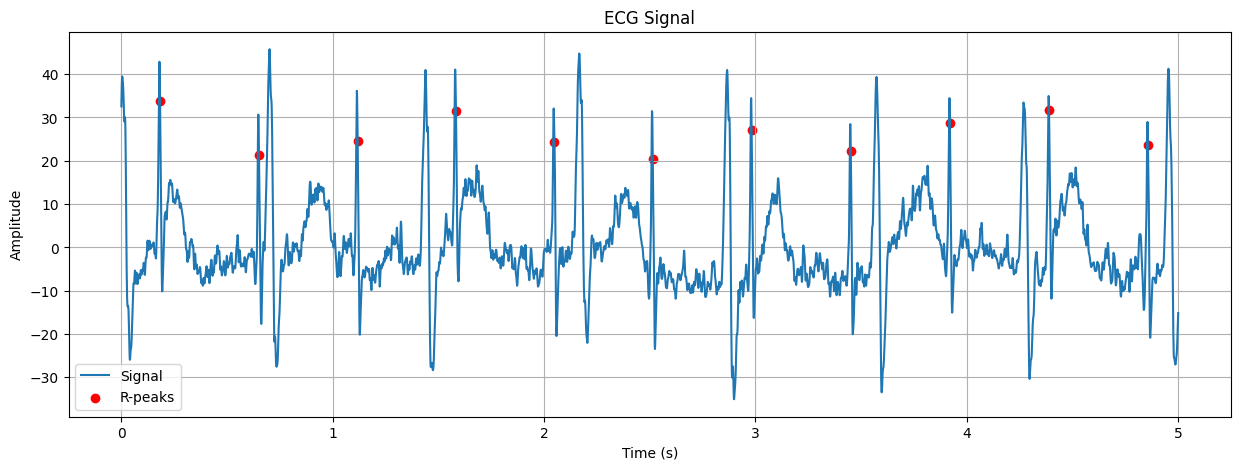

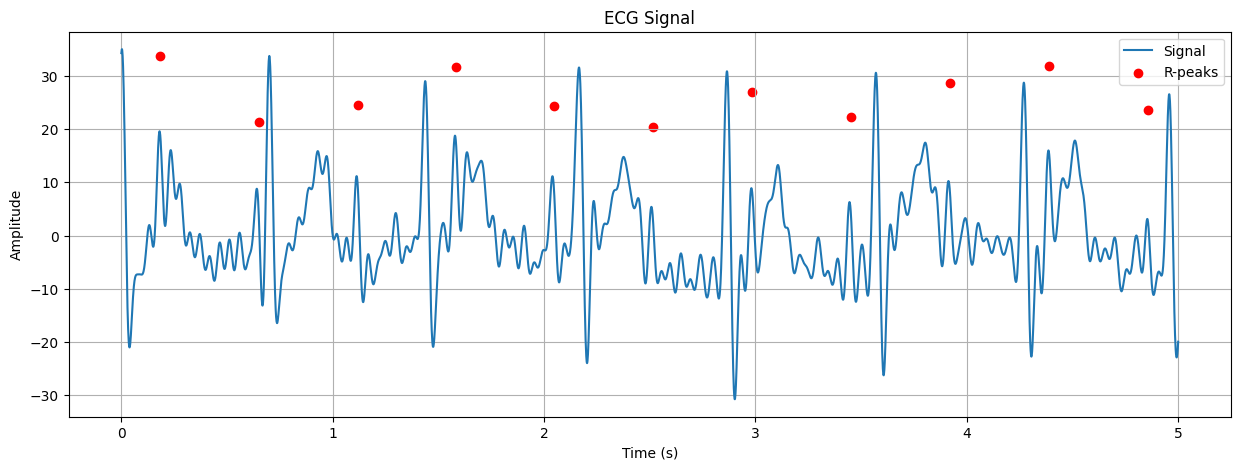

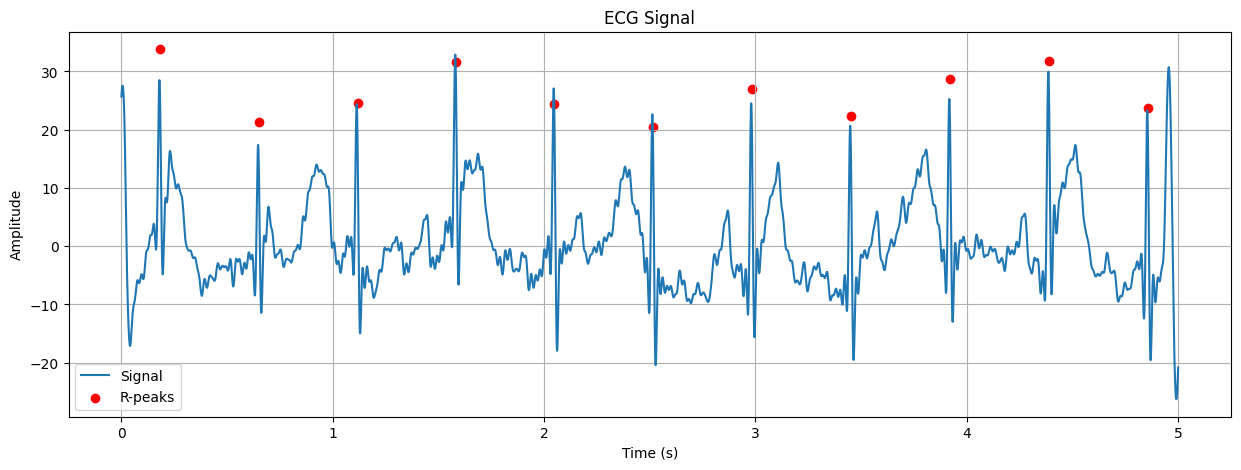

In [29]:
plot_signal(segment_4['segment'], segment_4['time'], segment_4['onsets'], segment_4['values'])
plot_signal(mecg, segment_4['time'], segment_4['onsets'], segment_4['values'])
plot_signal(fecg, segment_4['time'], segment_4['onsets'], segment_4['values'])

## Applying SVD On All Segments

In [33]:
# get segment weights
weights = get_signal_weights([segment_1, segment_2, segment_3, segment_4])

# extract signals using SVD
mecg_1 = hankel_with_svd(segment_1['segment'])
mecg_2 = hankel_with_svd(segment_2['segment'])
mecg_3 = hankel_with_svd(segment_3['segment'])
mecg_4 = hankel_with_svd(segment_4['segment'])

_, mecg_info_1 = nk.ecg_peaks(mecg_1, sampling_rate=1000, correct_artifacts=True)
_, mecg_info_2 = nk.ecg_peaks(mecg_2, sampling_rate=1000, correct_artifacts=True)
_, mecg_info_3 = nk.ecg_peaks(mecg_3, sampling_rate=1000, correct_artifacts=True)
_, mecg_info_4 = nk.ecg_peaks(mecg_4, sampling_rate=1000, correct_artifacts=True)

fecg_1 = hankel_with_svd(lower_peaks(segment_1['segment'], peaks=mecg_info_1['ECG_R_Peaks']), cvp=0.95)
fecg_2 = hankel_with_svd(lower_peaks(segment_2['segment'], peaks=mecg_info_2['ECG_R_Peaks']), cvp=0.95)
fecg_3 = hankel_with_svd(lower_peaks(segment_3['segment'], peaks=mecg_info_3['ECG_R_Peaks']), cvp=0.95)
fecg_4 = hankel_with_svd(lower_peaks(segment_4['segment'], peaks=mecg_info_4['ECG_R_Peaks']), cvp=0.95)

mecg_mean = np.mean([mecg_1, mecg_2, mecg_3, mecg_4], axis=0)
fecg_mean = np.mean([fecg_1, fecg_2, fecg_3, fecg_4], axis=0)

# obtain a single segment using weights
mecg = (
    weights[0]*mecg_1 +
    weights[1]*mecg_2 +
    weights[2]*mecg_3 +
    weights[3]*mecg_4
)

fecg = (
    weights[0]*fecg_1 +
    weights[1]*fecg_2 +
    weights[2]*fecg_3 +
    weights[3]*fecg_4
)

# sum of every result
_, info = nk.ecg_peaks(fecg_mean[:5000], sampling_rate=1000, correct_artifacts=True)
print("Accuracy:", get_classification_report(direct_segment['onsets'], info['ECG_R_Peaks']*1e-3)['accuracy'])

# weighted sum of every result
_, info = nk.ecg_peaks(fecg[:5000], sampling_rate=1000, correct_artifacts=True)
print("Accuracy:", get_classification_report(direct_segment['onsets'], info['ECG_R_Peaks']*1e-3)['accuracy'])

Accuracy: 81.81818181818183
Accuracy: 81.81818181818183


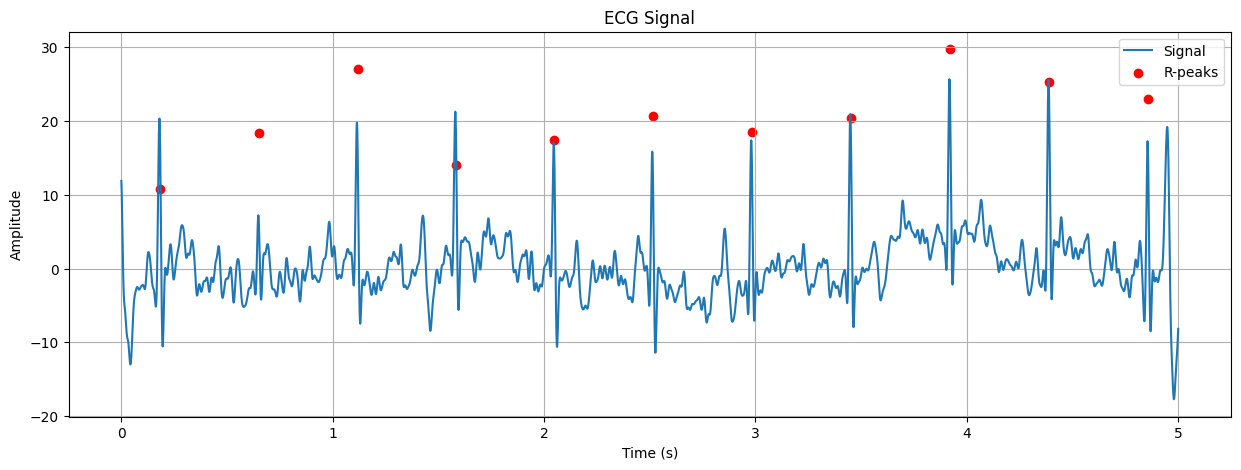

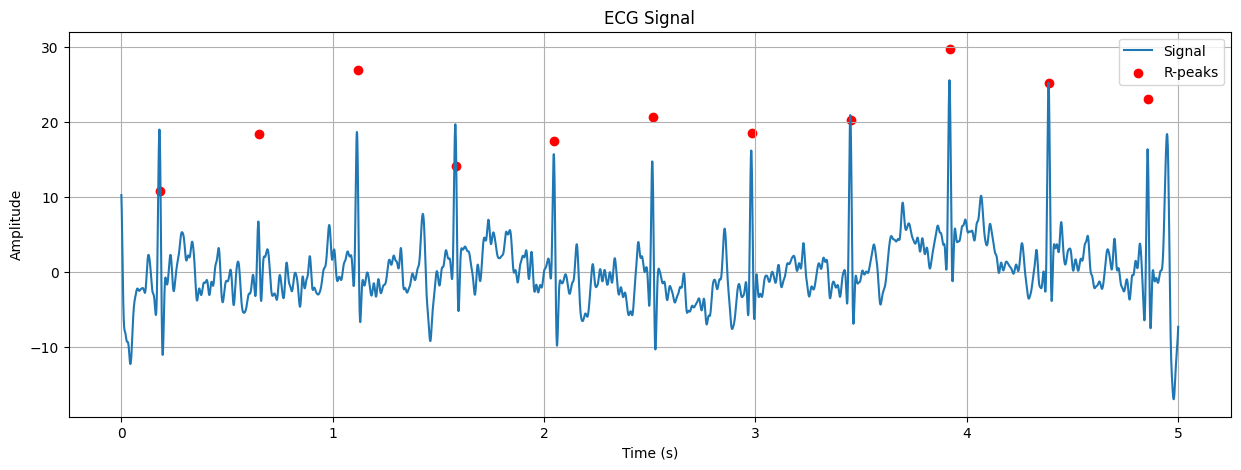

In [34]:
# plot_signal(mecg*10, segment_1['time'], segment_1['onsets'], segment_1['values'])
# plot_signal(mecg_1+mecg_2+mecg_3+mecg_4, segment_1['time'], segment_1['onsets'], segment_1['values'])
plot_signal(fecg, segment_1['time'], segment_1['onsets'], segment_1['values'])
plot_signal(fecg_mean, segment_1['time'], segment_1['onsets'], segment_1['values'])

## Applying FastICA On All Signals

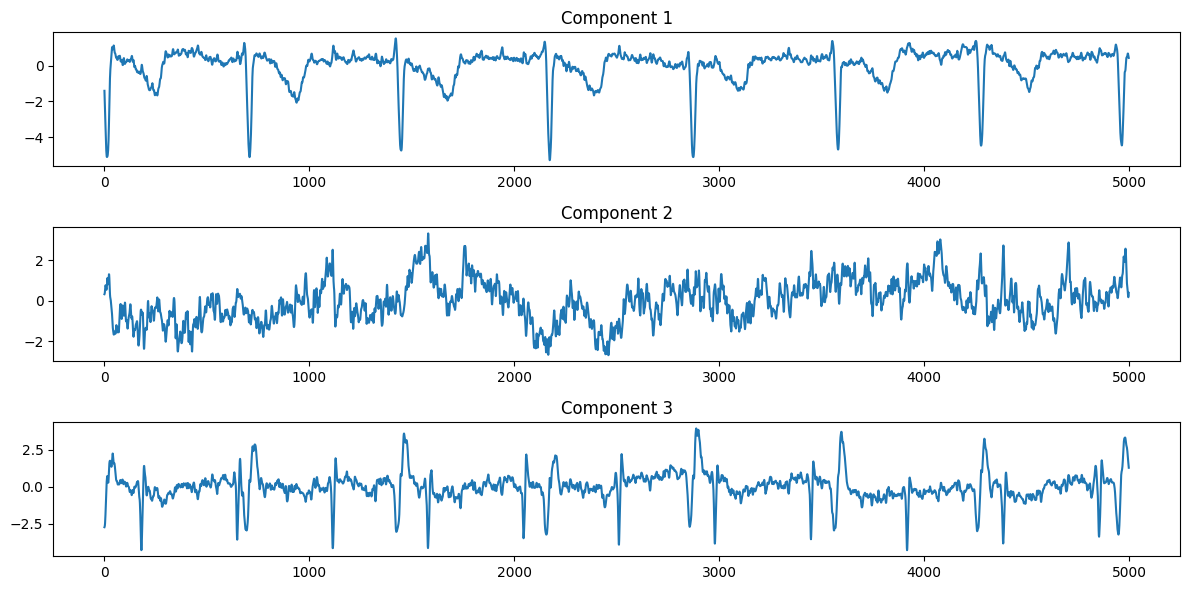

In [10]:
matrix = np.stack([
    segment_1['segment'], 
    segment_2['segment'], 
    segment_3['segment'], 
    segment_4['segment']
], axis=0)  # shape (4, N)

X = matrix.T

n_sources = 3  # mECG, fECG, noise
ica = FastICA(n_components=n_sources, random_state=0, max_iter=1000)

# independent sources
S_ = ica.fit_transform(X)   # shape: (N, 3)
# mixing matrix
A_ = ica.mixing_             # shape: (4, 3)

plt.figure(figsize=(12, 6))
for i in range(S_.shape[1]):
    plt.subplot(n_sources, 1, i + 1)
    plt.plot(S_[:, i])
    plt.title(f"Component {i+1}")
plt.tight_layout()
plt.show()


Accuracy: 81.81818181818183


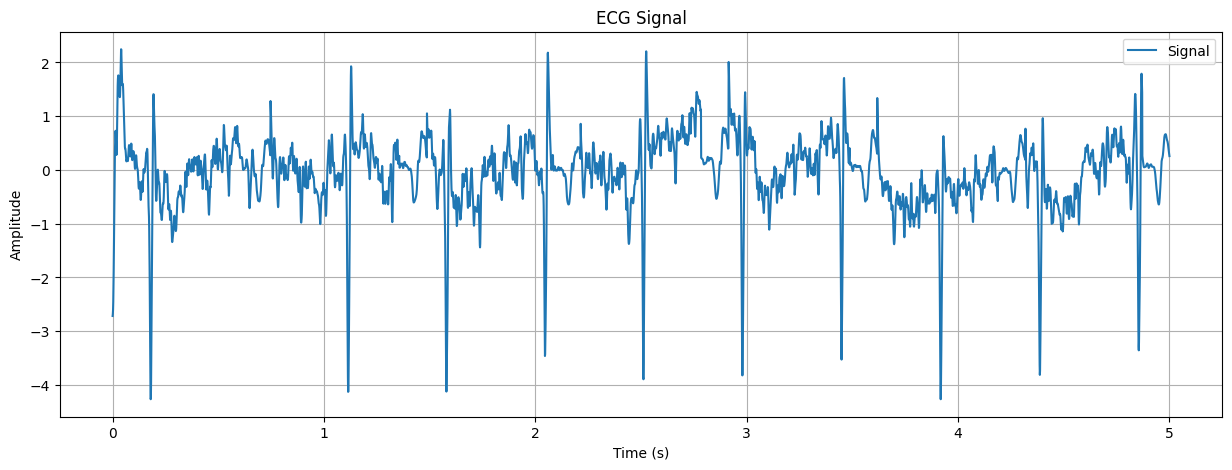

In [11]:
_, ica_info = nk.ecg_peaks(S_[:, 0], sampling_rate=1000, correct_artifacts=True)
ica_fecg = lower_peaks(S_[:, 2], peaks=ica_info['ECG_R_Peaks'], neighborhood=65)
_, ica_fecg_info = nk.ecg_peaks(ica_fecg, sampling_rate=1000, correct_artifacts=True)
print("Accuracy:", get_classification_report(direct_segment['onsets'], ica_fecg_info['ECG_R_Peaks']*1e-3)['accuracy'])
plot_signal(ica_fecg, segment_1['time'])

## Applying SVD On Unfolded Tensor

np.float64(50.0)

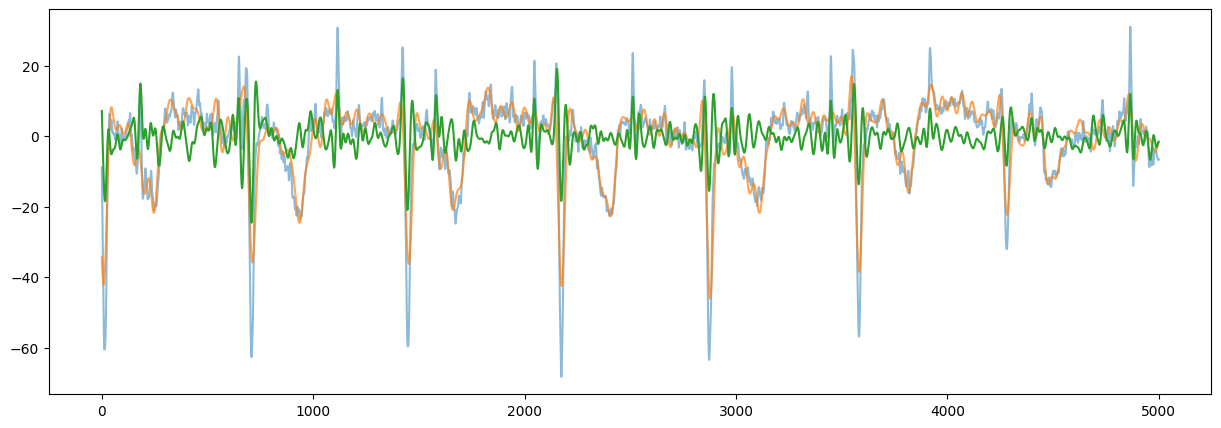

In [55]:
# unfold the tensor on mode-2
unfolded_tensor = segment_tensor.reshape(L, K*4)
H = np.hstack((segment_matrix_1, segment_matrix_2, segment_matrix_3, segment_matrix_4))

U, s, Vt = np.linalg.svd(H, full_matrices=False)

var_explained = s**2 / np.sum(s**2)
cumulative_var = np.cumsum(var_explained)

k1 = np.argmax(cumulative_var >= 0.75) + 1
k2 = np.argmax(cumulative_var >= 0.95) + 1
# print(f"Selected components:")
# print(f" - mECG: 1..{k1}")
# print(f" - fECG: {k1+1}..{k2}")
# print(f" - Noise: >{k2}")

H_mecg = U[:, :k1] @ np.diag(s[:k1]) @ Vt[:k1, :] 
H_fecg = U[:, k1:k2] @ np.diag(s[k1:k2]) @ Vt[k1:k2, :]
H_noise = U[:, k2:] @ np.diag(s[k2:]) @ Vt[k2:, :]

mECG_signals = diagonal_averaging(H_mecg)
fECG_signals = diagonal_averaging(H_fecg)
noise_signals = diagonal_averaging(H_noise)

plt.figure(figsize=(15, 5))
plt.plot(diagonal_averaging(H)[:5000], alpha=0.5)
plt.plot(mECG_signals[:5000], alpha=0.7)
plt.plot(fECG_signals[:5000])

_, info = nk.ecg_peaks(fECG_signals[:5000], sampling_rate=1000, correct_artifacts=True)
get_classification_report(direct_segment['onsets'], info['ECG_R_Peaks']*1e-3)['accuracy']

## Applying Tucker On Segment Tensor

In [8]:
# assess the quality of each channel
quality = [
    signal_quality(segment_1['segment'])['best_quality'],
    signal_quality(segment_2['segment'])['best_quality'],
    signal_quality(segment_3['segment'])['best_quality'],
    signal_quality(segment_4['segment'])['best_quality']
]

weights = quality / np.sum(quality)
weights

# assess the best rank for each channel
tucker_rank = get_tucker_rank([segment_1, segment_2, segment_3, segment_4], mode='best')

In [35]:
core, factors = tucker(segment_tensor, rank=[tucker_rank, tucker_rank, 4])
U_L, U_K, U_C = factors

S_mecg = np.zeros_like(core)
S_mecg[:, :, 0] = core[:, :, 0]  # Assign the first component to mECG

S_fecg = np.zeros_like(core)
S_fecg[:, :, 1:] = core[:, :, 1:]  # Assign the remaining components to fECG

# Reconstruct partial tensors for mECG, fECG, and noise
H_mecg = tl.tucker_to_tensor((S_mecg, factors))
H_fecg = tl.tucker_to_tensor((S_fecg, factors))
H_noise = segment_tensor - (H_mecg + H_fecg)

# Function to reconstruct signals for each channel from a tensor
def reconstruct_channels(H_block):
    L, K, C = H_block.shape
    reconstructed = []
    for c in range(C):  # Iterate over channels
        x_rec = diagonal_averaging(H_block[:, :, c])  # Perform diagonal averaging
        reconstructed.append(x_rec)
    return reconstructed

# Reconstruct signals for mECG, fECG, and noise
mECG_signals = reconstruct_channels(H_mecg)
fECG_signals = reconstruct_channels(H_fecg)
noise_signals = reconstruct_channels(H_noise)

# Weighted combination of signals from all channels
mECG_combined = np.sum(np.array(mECG_signals) * weights[:, None], axis=0)
fECG_combined = np.sum(np.array(fECG_signals) * weights[:, None], axis=0)
noise_combined = np.sum(np.array(noise_signals) * weights[:, None], axis=0)

_, info = nk.ecg_peaks(noise_combined, sampling_rate=1000, correct_artifacts=True)
print("Accuracy:", get_classification_report(direct_segment['onsets'], info['ECG_R_Peaks']*1e-3)['accuracy'])

Accuracy: 90.9090909090909


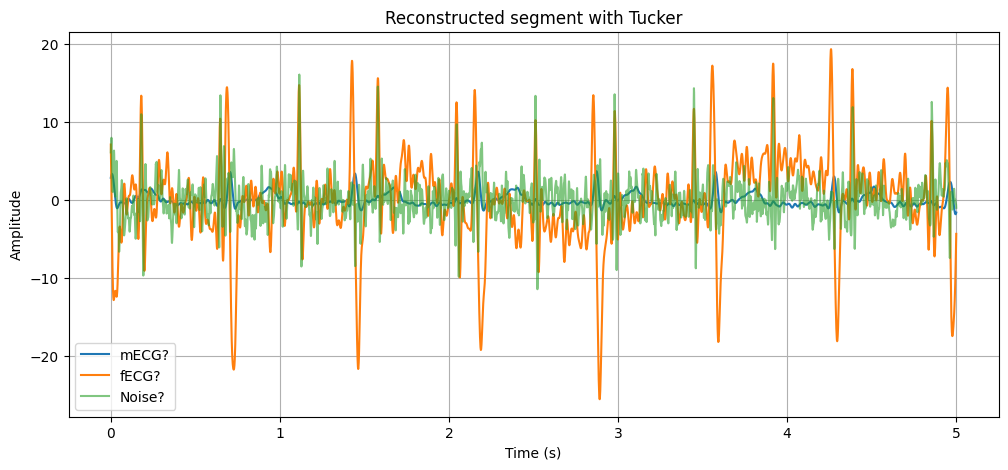

In [36]:
time = np.linspace(0, len(mECG_combined)/1000, len(mECG_combined))  # Time in seconds

# Plot the results
plt.figure(figsize=(12, 5))
plt.plot(time, mECG_combined, label='mECG?', color='C0')  # periodicity
plt.plot(time, fECG_combined, label='fECG?', color='C1')  # mECG
plt.plot(time, noise_combined, label='Noise?', color='C2', alpha=0.6)  # fECG
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('Reconstructed segment with Tucker')
plt.legend()
plt.grid(True)
plt.show()

## Applying SVD On Full Signal

In [15]:
segment_length = 5
overlap = 0.5

curr_start = 0
total_duration = signal_4['time'][-1]

mecgs = []
fecgs = []
# times = []
onsets_list = []
onsets_values_list = []

full_length = int(total_duration*1000)
combined_mecg = np.zeros(full_length)
combined_fecg = np.zeros(full_length)
weights_m = np.zeros(full_length)
weights_f = np.zeros(full_length)

In [ ]:
while curr_start < total_duration:
    curr_end = min(curr_start + segment_length, total_duration)
    segment = get_signal_segment(ch_number=4, start_time=curr_start, end_time=curr_end)
    
    mecg = hankel_with_svd(segment['segment'])
    if mecg is None or len(mecg) == 0 or np.all(np.isnan(mecg)):
        logger.warning(f"Skipping segment {curr_start:.1f}-{curr_end:.1f}: invalid mECG")
        curr_start += segment_length - overlap
        continue
    
    mecg = np.nan_to_num(mecg)
    try:
        _, mecg_info = nk.ecg_peaks(-mecg, sampling_rate=1000, correct_artifacts=True)
    except Exception as e:
        logger.warning(f"Peak detection failed ({curr_start:.1f}-{curr_end:.1f}): {e}")
        curr_start += segment_length - overlap
        continue
    
    residual = lower_peaks(segment['segment'], peaks=mecg_info["ECG_R_Peaks"])
    fecg = hankel_with_svd(residual, window_length=454*2, cvp=0.9)
    if fecg is None or len(fecg) == 0 or np.all(np.isnan(fecg)):
        logger.warning(f"Skipping fECG at {curr_start:.1f}-{curr_end:.1f}: invalid extraction")
        curr_start += segment_length - overlap
        continue
    
    mecgs.append(mecg)
    fecgs.append(fecg)
    # times.append(segment['time'])
    onsets_list.append(segment['onsets'])
    onsets_values_list.append(segment['values'])

    window = hann(len(mecg))
    start_idx = int(curr_start*1000)
    end_idx = min(start_idx + len(window), full_length)
    w = window[: end_idx - start_idx]

    combined_mecg[start_idx:end_idx] += mecg[: len(w)] * w
    combined_fecg[start_idx:end_idx] += fecg[: len(w)] * w
    weights_m[start_idx:end_idx] += w
    weights_f[start_idx:end_idx] += w

    curr_start += segment_length - overlap

combined_mecg /= np.maximum(weights_m, 1e-8)
combined_fecg /= np.maximum(weights_f, 1e-8)

full_mecg = combined_mecg
full_fecg = combined_fecg
full_time = np.arange(full_length) / 1000
full_onsets = np.concatenate(onsets_list) if any(len(x) > 0 for x in onsets_list) else np.array([])
full_onsets_values = np.concatenate(onsets_values_list) if any(len(x) > 0 for x in onsets_values_list) else np.array([])

_, info = nk.ecg_peaks(full_fecg, sampling_rate=1000, correct_artifacts=True)
get_classification_report(direct_signal['onsets'], info['ECG_R_Peaks']*1e-3)['accuracy']

c:\Users\Ester\Desktop\ecg-svd\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\Ester\Desktop\ecg-svd\.venv\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\Ester\Desktop\ecg-svd\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\Ester\Desktop\ecg-svd\.venv\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\Ester\Desktop\ecg-svd\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\Ester\Desktop\ecg-svd\.venv\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid valu

np.float64(65.79330422125183)

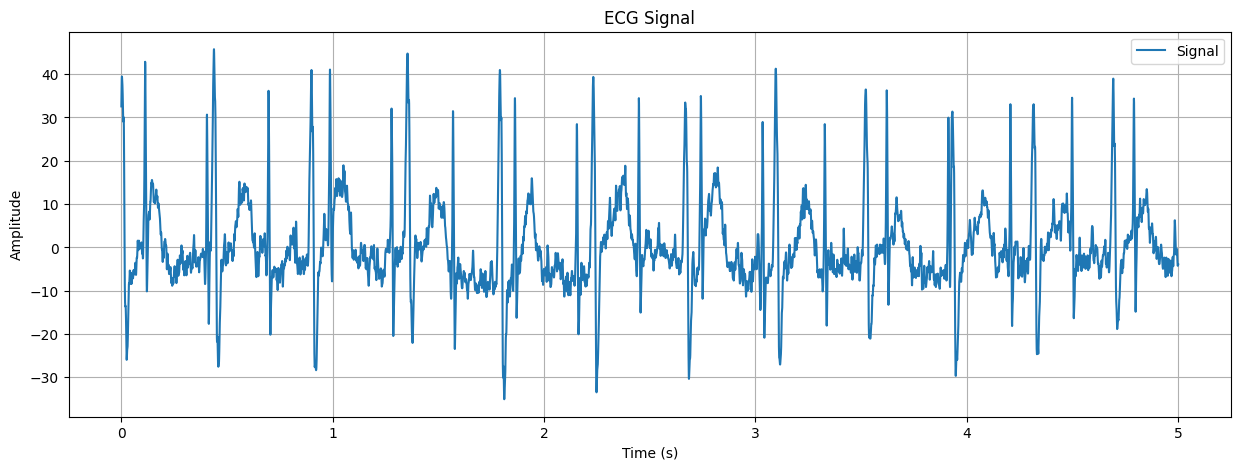

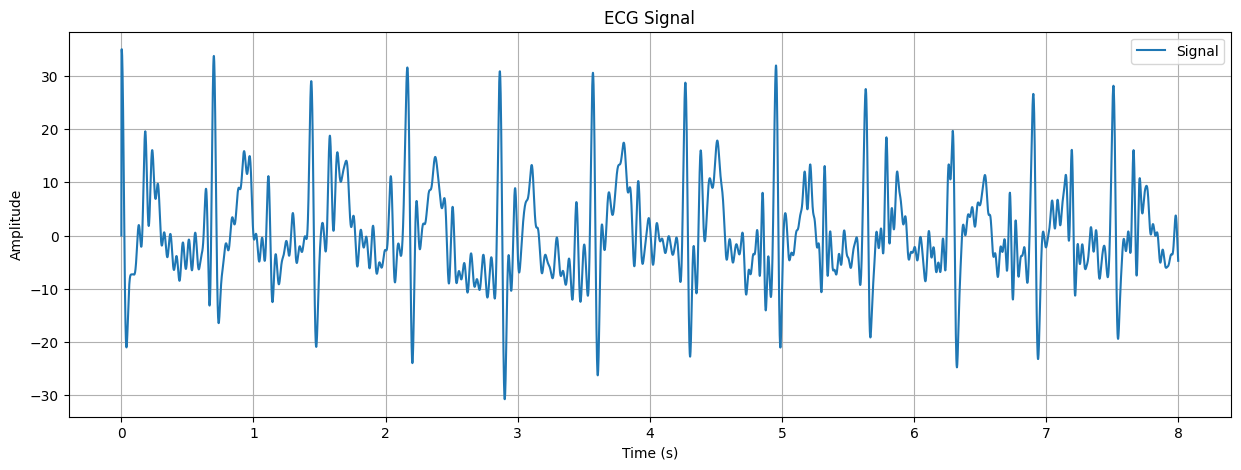

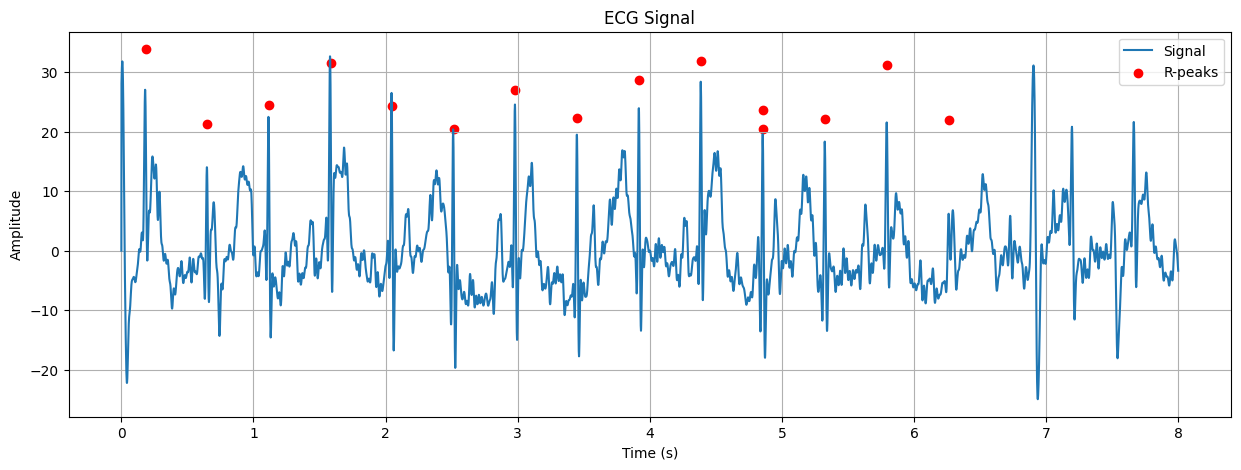

In [26]:
plot_signal(signal_4['segment'][:8000], np.linspace(0, 5, 8000))
plot_signal(full_mecg[:8000], full_time[:8000])
plot_signal(full_fecg[:8000], full_time[:8000], full_onsets[:15], full_onsets_values[:15])

## Applying Tucker On Full Signal (GPU)

In [40]:
total_duration = signal_4['time'][-1]
curr_start = 0

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
logger.info(f"Using device: {device}")

signal_full = torch.tensor(signal_4['segment'], device=device, dtype=torch.float32)
full_mecg = torch.zeros_like(signal_full, device=device)
full_fecg = torch.zeros_like(signal_full, device=device)
full_noise = torch.zeros_like(signal_full, device=device)
weights_final = torch.zeros_like(signal_full, device=device)

tl.set_backend('pytorch')
weights = torch.tensor(quality / np.sum(quality), device=device, dtype=torch.float32)

2025-11-01 20:41:15.603 | INFO     | __main__:<module>:5 - Using device: cuda


In [41]:
while curr_start < total_duration:
    curr_end = min(curr_start + segment_length, total_duration)
    
    hankels = []
    
    for ch in [1, 2, 3, 4]:
        segment = get_signal_segment(ch_number=ch, start_time=curr_start, end_time=curr_end)['segment']
        hankels.append(torch.tensor(hankel(segment[:L], segment[L-1:]), device=device, dtype=torch.float32))
        
    segment_tensor = torch.stack(hankels, dim=2).to(device)
    L, K, C = segment_tensor.shape
    
    rank = [tucker_rank, tucker_rank, 4]
    core, factors = tucker(segment_tensor, rank=rank, tol=1e-1)
    U_L, U_K, U_C = factors
    
    S_mecg = torch.zeros_like(core, device=device)
    S_mecg[:,:,0] = core[:,:,0]

    S_fecg = torch.zeros_like(core, device=device)
    S_fecg[:,:,1:] = core[:,:,1:]

    H_mecg = tl.tucker_to_tensor((S_mecg, factors))
    H_fecg = tl.tucker_to_tensor((S_fecg, factors))
    H_noise = segment_tensor - (H_mecg + H_fecg)
    
    def reconstruct_channels(H_block):
        L, K, C = H_block.shape
        rec = torch.stack([diagonal_averaging_torch(H_block[:, :, c]) for c in range(C)], dim=1)
        return rec
    
    mECG_signals = reconstruct_channels(H_mecg).to(device)
    fECG_signals = reconstruct_channels(H_fecg).to(device)
    noise_signals = reconstruct_channels(H_noise).to(device)

    mECG_seg = torch.sum(mECG_signals * weights[None, :], dim=1)
    fECG_seg = torch.sum(fECG_signals * weights[None, :], dim=1)
    noise_seg = torch.sum(noise_signals * weights[None, :], dim=1)

    window = torch.tensor(hann(len(mECG_seg)), device=device, dtype=torch.float32)
    start_idx = int(curr_start*1000)
    end_idx = min(start_idx + len(window), full_mecg.size(0))
    w = window[:end_idx - start_idx]

    full_mecg[start_idx:end_idx] += mECG_seg[:len(w)] * w
    full_fecg[start_idx:end_idx] += fECG_seg[:len(w)] * w
    full_noise[start_idx:end_idx] += noise_seg[:len(w)] * w
    weights_final[start_idx:end_idx] += w

    curr_start += segment_length - overlap

full_mecg /= torch.maximum(weights_final, torch.tensor(1e-8, device=device)) # periodicity
full_fecg /= torch.maximum(weights_final, torch.tensor(1e-8, device=device)) # mECG
full_noise /= torch.maximum(weights_final, torch.tensor(1e-8, device=device)) # fECG

_, info = nk.ecg_peaks(full_noise.cpu().numpy(), sampling_rate=1000, correct_artifacts=True)
get_classification_report(direct_signal['onsets'], info['ECG_R_Peaks']*1e-3)['accuracy']

np.float64(97.68875192604007)

In [42]:
_, info = nk.ecg_peaks(full_noise.cpu().numpy(), sampling_rate=1000, correct_artifacts=True)
get_classification_report(direct_signal['onsets'], info['ECG_R_Peaks']*1e-3)

{'TP': 634,
 'FN': 10,
 'FP': 5,
 'TN': 0,
 'accuracy': np.float64(97.68875192604007),
 'precision': np.float64(99.21752738654148),
 'recall': np.float64(98.4472049689441)}

## Applying PARAFAC On Segment Tensor

In [13]:
from tensorly.decomposition import parafac

rank = 4
weights, factors = parafac(segment_tensor, rank=rank, init='random', tol=1e-2, n_iter_max=500)
U_L, U_K, U_C = factors

components = []
for r in range(rank):
    comp = weights[r] * np.outer(U_L[:, r], U_K[:, r])[:, :, None] * U_C[None, None, r]
    components.append(comp)

components = np.stack(components, axis=-1)  # (L, K, C, rank)

S_mecg = np.sum(components[:, :, :, [0]], axis=-1)
S_fecg = np.sum(components[:, :, :, [1, 2]], axis=-1)
S_noise = segment_tensor - (S_mecg + S_fecg)

def reconstruct_channels(H_block):
    L, K, C = H_block.shape
    reconstructed = []
    for c in range(C):
        x_rec = diagonal_averaging(H_block[:, :, c])
        reconstructed.append(x_rec)
    return reconstructed

mECG_signals = reconstruct_channels(S_mecg)
fECG_signals = reconstruct_channels(S_fecg)
noise_signals = reconstruct_channels(S_noise)

mECG_combined = np.sum(np.array(mECG_signals) * weights[:, None], axis=0)
fECG_combined = np.sum(np.array(fECG_signals) * weights[:, None], axis=0)
noise_combined = np.sum(np.array(noise_signals) * weights[:, None], axis=0)

_, info = nk.ecg_peaks(noise_combined, sampling_rate=1000, correct_artifacts=True)
print("Accuracy:", get_classification_report(direct_segment['onsets'], info['ECG_R_Peaks']*1e-3)['accuracy'])

Accuracy: 90.9090909090909
